# ④ 심화 분석 — 인구 Join & 역×시간 핫스팟
**11team · 서울 지하철 혼잡도 분석**

③ EDA에서 본 **방향성(업무지구 vs 베드타운)**을 외부 인구데이터로 **실증**하고,
운영 의사결정의 핵심인 **역×시간 혼잡 핫스팟**을 도출한다.

In [1]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt, seaborn as sns, matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
NAVY, RED, BLUE = '#1D3557', '#E63946', '#457B9D'

SUBWAY_DIR = r"C:/Users/최용우/Downloads/drive-download-20260625T013956Z-3-001/dataset"
EXT_DIR    = r"C:/Users/최용우/claude/yearsubway_11team/external_data"
def read_csv_auto(p, **k):
    for e in ['utf-8-sig','cp949','euc-kr','utf-8']:
        try: return pd.read_csv(p, encoding=e, **k)
        except UnicodeDecodeError: continue

metro = read_csv_auto(f"{SUBWAY_DIR}/Seoul_subway_data_20210705.csv")
loc   = read_csv_auto(f"{SUBWAY_DIR}/subway_location_data.csv")
on_cols  = [c for c in metro.columns if '승차인원' in c]
off_cols = [c for c in metro.columns if '하차인원' in c]
slots    = [c.replace(' 승차인원','') for c in on_cols]
jun = metro[metro['사용월']==202106].copy()
jun['총승차'] = jun[on_cols].sum(axis=1)
print("2021.06 :", jun.shape, "/ 역", jun['지하철역'].nunique(), "개")

2021.06 : (608, 53) / 역 520 개


## 1. 역 → 자치구 매핑
좌표 데이터의 `주소`에서 자치구를 추출한다.
- **서울 외(경기·인천 등) 역은 서울교통공사 운영범위 밖** → 분석 대상에서 제외
- `서울역`은 좌표 데이터 누락이라 수동 보정(중구)

In [2]:
def keyf(x):   # 역명 정규화: 괄호·끝'역' 제거 → metro와 좌표 매칭 키
    return re.sub(r'역$','', re.sub(r'\(.*?\)','', str(x))).strip()
def get_gu(addr):
    p = str(addr).split()
    return p[1] if p and p[0].startswith('서울') else None

loc['key'] = loc['지하철역'].apply(keyf)
loc['자치구'] = loc['주소'].apply(get_gu)
loc_key = loc.dropna(subset=['자치구']).drop_duplicates('key').set_index('key')['자치구']

st = jun.groupby('지하철역')[on_cols + off_cols].sum()
st.columns = [c for c in on_cols] + [c for c in off_cols]
st = st.reset_index()
st['key'] = st['지하철역'].apply(keyf)
st['자치구'] = st['key'].map(loc_key)
st.loc[st['지하철역']=='서울역', '자치구'] = '중구'      # 좌표 누락 보정

seoul = st[st['자치구'].notna()].copy()
print(f"전체 {len(st)}역 → 서울 소재 {len(seoul)}역 (경기·인천 등 {len(st)-len(seoul)}역 제외)")

전체 520역 → 서울 소재 296역 (경기·인천 등 224역 제외)


## 2. 주간인구지수 Join — 방향성 실증
자치구 **주간인구지수**(주간/상주×100, 2020)를 Join.
역별 **아침(07–09시) 승차비율** = 아침승차/(아침승차+아침하차)와 비교한다.

In [3]:
ju = pd.read_excel(f"{EXT_DIR}/서울특별시_자치구별 연령별 주간 야간 인구_20201231.xlsx", header=1)
ju['행정구역별'] = ju['행정구역별'].ffill()
gu = ju[(ju['성별']=='계') & (ju['연령별']=='합계') & (ju['행정구역별']!='서울특별시')].copy()
gu['자치구'] = gu['행정구역별'].str.replace('　','',regex=False).str.strip()
gu_idx = gu.set_index('자치구')['주간 인구 지수']

am_on  = [c for c in on_cols  if c.startswith(('07시','08시'))]
am_off = [c for c in off_cols if c.startswith(('07시','08시'))]
seoul['아침승차'] = seoul[am_on].sum(axis=1)
seoul['아침하차'] = seoul[am_off].sum(axis=1)
seoul['아침승차비율'] = seoul['아침승차'] / (seoul['아침승차'] + seoul['아침하차'])
seoul['주간인구지수'] = seoul['자치구'].map(gu_idx)

v = seoul[(seoul['아침승차']+seoul['아침하차']) > 10000].dropna(subset=['주간인구지수'])
corr = v['주간인구지수'].corr(v['아침승차비율'])
print(f"분석역 {len(v)}개 | 주간인구지수 ↔ 아침승차비율 상관 = {corr:.3f}")

분석역 296개 | 주간인구지수 ↔ 아침승차비율 상관 = -0.672


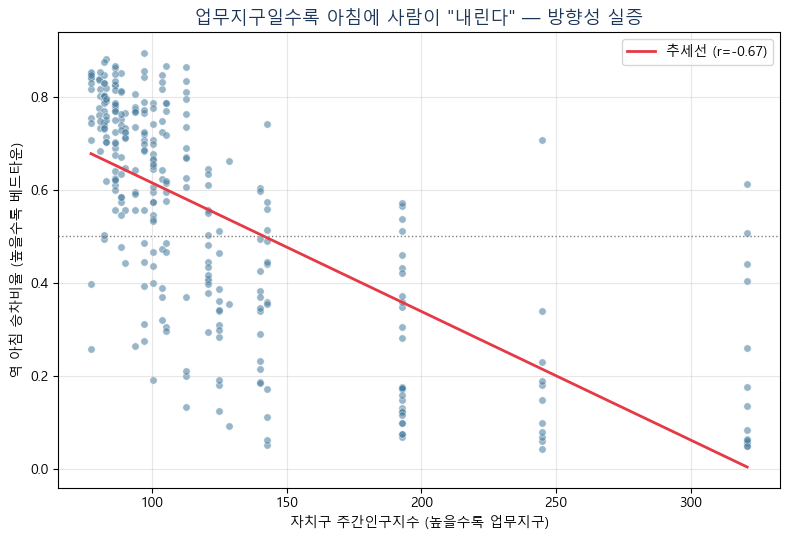

In [4]:
fig, ax = plt.subplots(figsize=(8,5.5))
ax.scatter(v['주간인구지수'], v['아침승차비율'], s=28, alpha=0.55, color=BLUE, edgecolors='white', lw=0.5)
m, b = np.polyfit(v['주간인구지수'], v['아침승차비율'], 1)
xs = np.array([v['주간인구지수'].min(), v['주간인구지수'].max()])
ax.plot(xs, m*xs+b, color=RED, lw=2, label=f'추세선 (r={corr:.2f})')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('자치구 주간인구지수 (높을수록 업무지구)')
ax.set_ylabel('역 아침 승차비율 (높을수록 베드타운)')
ax.set_title('업무지구일수록 아침에 사람이 "내린다" — 방향성 실증', color=NAVY, fontsize=13)
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**해석** — 강한 음의 상관(r≈−0.67). 주간인구지수가 높은 업무지구 역(중구·종로)일수록 아침 승차비율이 0.05 안팎으로 낮다 = **아침에 대부분 하차**(출근 유입). 반대로 주거지(강서·강북) 역은 0.9 가까이 = **아침에 대부분 승차**(출근 유출).
*(상관≠인과: 업무지구→일자리 집중→아침 유입이라는 구조가 배경)*

## 3. 역×시간 핫스팟 히트맵
승차 인원 상위 15개 역의 시간대별 승차량 — **어느 역·어느 시간**에 혼잡이 몰리는지 한눈에.

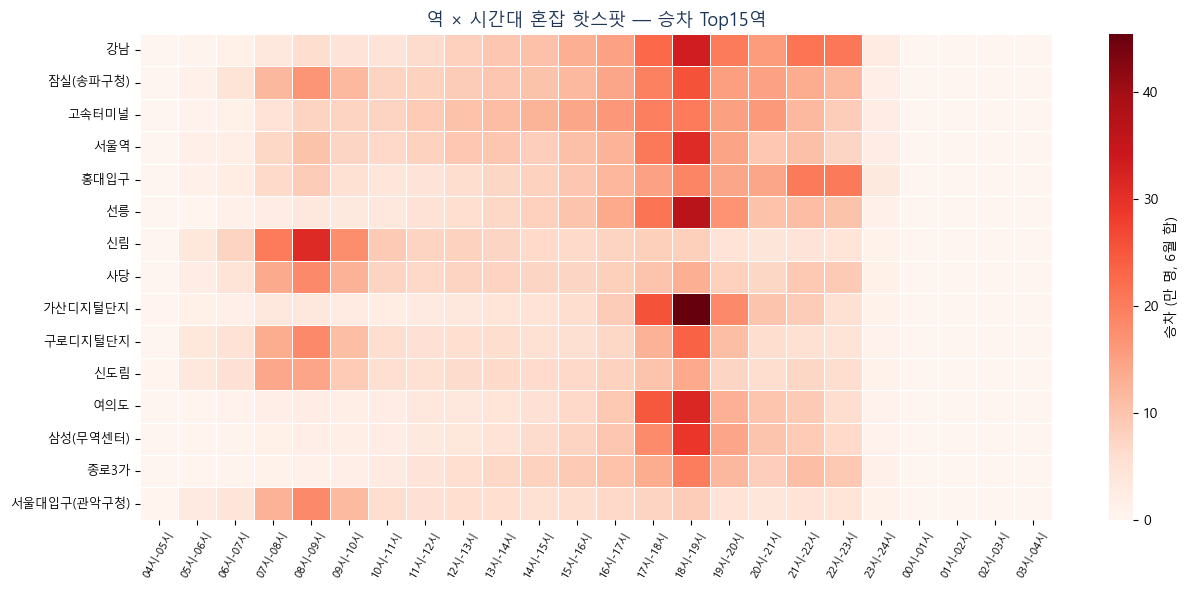

In [5]:
seoul_total = seoul.set_index('지하철역')[on_cols].sum(axis=1)
top15 = seoul_total.nlargest(15).index
mat = seoul.set_index('지하철역').loc[top15][on_cols]
mat.columns = slots
fig, ax = plt.subplots(figsize=(13,6))
sns.heatmap(mat/1e4, cmap='Reds', linewidths=.4, linecolor='white',
            cbar_kws={'label':'승차 (만 명, 6월 합)'}, ax=ax)
ax.set_title('역 × 시간대 혼잡 핫스팟 — 승차 Top15역', color=NAVY, fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=60, fontsize=8); plt.yticks(fontsize=9, rotation=0)
plt.tight_layout(); plt.show()

---
## ✅ 심화 분석 요약
- **방향성 실증**: 주간인구지수 ↔ 아침승차비율 상관 −0.67 → 업무지구/베드타운 구조 확인
- **핫스팟**: 승차 Top15역 × 시간대 히트맵으로 혼잡 집중 구간 가시화 (퇴근 18–19시 + 출근 08–09시 강남·잠실 등)

### ▶ 다음 (⑤ 솔루션)
- **folium 혼잡 지도**: 역별 혼잡도·피크시간 마커
- **자원배치 권고**: 핫스팟 점수화 → 증차·안전인력 우선순위(실현가능)